### 0. Setup

In [1]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)
import matplotlib.pyplot as plt

In [2]:
path = "Test O_G_Equipment_Data.xlsx"

metrics = ["Temperature", "Pressure", "VibrationX", "VibrationY", "VibrationZ", "Frequency"]
preset_cols = ["Preset_1", "Preset_2"]

In [3]:
df = pd.read_excel(path, engine="openpyxl")
df.head(15)

,Cycle,Preset_1,Preset_2,Temperature,Pressure,VibrationX,VibrationY,VibrationZ,Frequency,Fail
0,1,3,6,44.235186,47.657254,46.441769,64.820327,66.454520,44.483250,False
1,2,2,4,60.807234,63.172076,62.005951,80.714431,81.246405,60.228715,False
2,3,2,1,79.027536,83.032190,82.642110,98.254386,98.785196,80.993479,False
3,4,2,3,79.716242,100.508634,122.362321,121.363429,118.652538,80.315567,False
4,5,2,5,39.989054,51.764833,42.514302,61.037910,50.716469,64.245166,False
5,6,1,2,58.336085,64.426353,56.479227,78.623742,65.911528,78.886214,False
6,7,1,3,77.937777,83.146657,77.800590,109.679048,86.230728,99.681179,False
7,8,1,4,78.563506,130.089912,110.479871,130.997020,85.218562,98.467375,False
8,9,3,7,77.486218,104.462955,77.390388,159.423483,115.211934,98.900268,False
9,10,1,8,42.619159,48.343336,65.789156,49.524829,64.915090,41.620715,False


### 1. Calculate how many times the equipment has failed.


In [4]:
df_fail = df[df["Fail"] == True]
df_fail.shape[0]
print(f"The equipment has failed {df_fail.shape[0]} times.")


The equipment has failed 66 times.


### 2. Categorize equipment failures by setup configurations (Preset 1 and Preset 2).


In [5]:
preset_failure_summary = (
    df.groupby(preset_cols)
      .agg(Total=("Fail", "size"), Failure_Count=("Fail", "sum"))
      .reset_index()
)
preset_failure_summary["Failure_Rate"] = (
    preset_failure_summary["Failure_Count"] / preset_failure_summary["Total"]
)
preset_failure_summary = preset_failure_summary.sort_values(
    ["Failure_Rate", "Total"], ascending=[False, False]
).reset_index(drop=True)

print("Failure summary by Preset_1 / Preset_2 combination")
display(preset_failure_summary)

print("Combinations with no failures")
display(
    preset_failure_summary[preset_failure_summary["Failure_Count"] == 0].sort_values(
        "Total", ascending=False
    )
)

preset_metrics_by_fail = (
    df.groupby(preset_cols + ["Fail"])[metrics]
      .mean()
      .reset_index()
      .sort_values(preset_cols + ["Fail"])
)
print("Average metrics by Preset_1 / Preset_2 combination and Fail status")
display(preset_metrics_by_fail)

Failure summary by Preset_1 / Preset_2 combination


,Preset_1,Preset_2,Total,Failure_Count,Failure_Rate
0,1,5,31,5,0.161290
1,3,5,29,4,0.137931
2,2,1,30,4,0.133333
3,1,2,38,5,0.131579
4,1,1,34,4,0.117647
5,2,8,37,4,0.108108
6,1,7,38,4,0.105263
7,3,6,30,3,0.100000
8,3,1,31,3,0.096774
9,1,4,22,2,0.090909


Combinations with no failures


,Preset_1,Preset_2,Total,Failure_Count,Failure_Rate
23,3,4,31,0,0.0


Average metrics by Preset_1 / Preset_2 combination and Fail status


,Preset_1,Preset_2,Fail,Temperature,Pressure,VibrationX,VibrationY,VibrationZ,Frequency
0,1,1,False,71.668814,87.756997,74.330724,73.342660,72.717382,61.733127
1,1,1,True,88.701785,148.364906,98.490239,148.424130,81.417281,104.308590
2,1,2,False,61.714806,73.444246,68.820931,70.172782,64.899285,69.415367
3,1,2,True,80.958556,95.883935,115.611221,103.112071,122.002333,94.425227
4,1,3,False,59.118439,69.508540,67.082983,62.847496,65.385246,68.116503
5,1,3,True,99.585616,124.880291,120.487285,99.698893,95.582167,94.848272
6,1,4,False,59.123855,75.554373,74.071300,68.868094,66.506642,58.652703
7,1,4,True,64.881282,135.484522,86.144002,155.177493,119.690705,90.886321
8,1,5,False,69.691197,72.897792,69.988324,70.452984,71.912864,62.433166
9,1,5,True,91.260240,135.600610,90.795101,137.215269,99.645767,136.918966


When analyzing the data above, we can see a higher occurrence of errors in preset combinations, especially in runs 1-5 and 3-5.

We also found that preset 3-4 did not present any failures in the sample data.

When comparing the averages for presets with and without failures, we can note that those with failures tend to have higher values than those without failures.

### 3. Categorize equipment failures by their nature/root cause according to parameter readings

In [6]:
# Split datasets
df_fail = df[df.get("Fail") == True]
df_ok = df[df.get("Fail") == False]

#Effect size (Cohen's d) between failed and ok runs for each metric
effect_sizes = []
for m in metrics:
    f_mean = df_fail[m].mean()
    o_mean = df_ok[m].mean()
    f_std = df_fail[m].std()
    o_std = df_ok[m].std()
    pooled = np.sqrt((f_std**2 + o_std**2) / 2) if (not np.isnan(f_std) and not np.isnan(o_std)) else np.nan
    d = (f_mean - o_mean) / pooled if pooled and pooled != 0 else np.nan
    effect_sizes.append((m, d, f_mean, o_mean, f_std, o_std))

es_df = pd.DataFrame(effect_sizes, columns=["Metric", "Cohens_d", "Mean_Fail", "Mean_Ok", "Std_Fail", "Std_Ok"]).set_index("Metric")
print("Effect sizes (Cohen's d) — positive means higher in failed runs")
display(es_df.sort_values("Cohens_d", key=lambda s: s.abs(), ascending=False))

#Correlation of each metric with Fail flag
corr_with_fail = df[metrics].corrwith(df["Fail"].astype(int), method='pearson').dropna()
corr_df = corr_with_fail.to_frame("corr_with_fail").reset_index().rename(columns={"index":"Metric"}).set_index('Metric')
print("\nPearson correlation with Fail Flag")
display(corr_df.sort_values("corr_with_fail", key=lambda s: s.abs(), ascending=False))

Effect sizes (Cohen's d) — positive means higher in failed runs


,Cohens_d,Mean_Fail,Mean_Ok,Std_Fail,Std_Ok
Metric,,,,,
VibrationY,1.808419,122.481159,68.318455,30.861777,29.010220
VibrationZ,1.374891,106.003200,68.796672,28.377486,25.678027
Frequency,1.346298,99.812745,65.382995,22.960578,27.943436
Pressure,1.346109,116.422540,75.632790,30.040055,30.561615
Temperature,1.085166,92.469125,67.176884,21.683670,24.824880
VibrationX,0.979070,100.167190,71.494803,28.109402,30.415831



Pearson correlation with Fail Flag


,corr_with_fail
Metric,
VibrationY,0.455435
VibrationZ,0.367857
Pressure,0.345497
Frequency,0.325286
Temperature,0.272666
VibrationX,0.252754


Analyzing the output above, we can see that VibrationY has the highest correlation with failures; higher values of this measurement are a strong indicator of failure

### 4. Create a model (or models) using the technique you think is most appropriate and measure its performance

In [7]:


# Select features and target
X = df[metrics].dropna()
y = df.loc[X.index, "Fail"].astype(int)

print(f"Total samples: {len(X)}")
print(f"Failures: {y.sum()} ({y.sum()/len(y)*100:.1f}%)")
print(f"No failures: {(1-y).sum()} ({(1-y).sum()/len(y)*100:.1f}%)")

# Train-test split (80-20 with stratification to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

# Standardize features for models that benefit from scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain set: {len(X_train)} | Test set: {len(X_test)}")
print(f"Train failures: {y_train.sum()} | Test failures: {y_test.sum()}")


Total samples: 800
Failures: 66 (8.2%)
No failures: 734 (91.8%)

Train set: 600 | Test set: 200
Train failures: 50 | Test failures: 16


Based on my knowledge, one of these models should be very effective for this type of analysis. I will test training one model from each and evaluate which one performs best in this case (we should perform cross-validations for better effectiveness in this analysis, but we will proceed in a more concise way this time).

- **Logistic Regression**
- **Random Forest**
- **Support Vector Machine (SVM)**
- **XGBoost**

We'll evaluate using: **Accuracy, Precision, Recall, F1-score, ROC-AUC, and Confusion Matrix**.

In [8]:

# 4.2) Train multiple classification models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "SVM (RBF)": SVC(kernel='rbf', probability=True, random_state=42),
    "xgboost": XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
}

results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training {model_name}...")
    print(f"{'='*60}")
    
    # Train on scaled data for SVM, original for tree-based
    if "SVM" in model_name:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
    cm = confusion_matrix(y_test, y_pred)
    
    results[model_name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'confusion_matrix': cm,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    if roc_auc:
        print(f"ROC-AUC:   {roc_auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Fail', 'Fail']))

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'F1-Score': [results[m]['f1'] for m in results.keys()],
    'ROC-AUC': [results[m]['roc_auc'] if results[m]['roc_auc'] is not None else 0 for m in results.keys()]
})

display(comparison_df.set_index('Model'))

print("\nBest models by metric:")
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    best_model = comparison_df.loc[comparison_df[metric].idxmax(), 'Model']
    best_score = comparison_df[metric].max()
    print(f"  {metric}: {best_model} ({best_score:.4f})")



Training Logistic Regression...
Accuracy:  0.9650
Precision: 0.8000
Recall:    0.7500
F1-Score:  0.7742
ROC-AUC:   0.9864

Confusion Matrix:
[[181   3]
 [  4  12]]

Classification Report:
              precision    recall  f1-score   support

     No Fail       0.98      0.98      0.98       184
        Fail       0.80      0.75      0.77        16

    accuracy                           0.96       200
   macro avg       0.89      0.87      0.88       200
weighted avg       0.96      0.96      0.96       200


Training Random Forest...
Accuracy:  0.9450
Precision: 0.7778
Recall:    0.4375
F1-Score:  0.5600
ROC-AUC:   0.9694

Confusion Matrix:
[[182   2]
 [  9   7]]

Classification Report:
              precision    recall  f1-score   support

     No Fail       0.95      0.99      0.97       184
        Fail       0.78      0.44      0.56        16

    accuracy                           0.94       200
   macro avg       0.87      0.71      0.77       200
weighted avg       0.94      

/home/flaviogaspareto/documents/vscode/Test_AI_ML_Engineer/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/flaviogaspareto/documents/vscode/Test_AI_ML_Engineer/.venv/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [02:49:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy:  0.9500
Precision: 0.7500
Recall:    0.5625
F1-Score:  0.6429
ROC-AUC:   0.9766

Confusion Matrix:
[[181   3]
 [  7   9]]

Classification Report:
              precision    recall  f1-score   support

     No Fail       0.96      0.98      0.97       184
        Fail       0.75      0.56      0.64        16

    accuracy                           0.95       200
   macro avg       0.86      0.77      0.81       200
weighted avg       0.95      0.95      0.95       200


MODEL COMPARISON


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.965,0.800000,0.7500,0.774194,0.986413
Random Forest,0.945,0.777778,0.4375,0.560000,0.969429
SVM (RBF),0.945,0.857143,0.3750,0.521739,0.965014
xgboost,0.950,0.750000,0.5625,0.642857,0.976562



Best models by metric:
  Accuracy: Logistic Regression (0.9650)
  Precision: SVM (RBF) (0.8571)
  Recall: Logistic Regression (0.7500)
  F1-Score: Logistic Regression (0.7742)
  ROC-AUC: Logistic Regression (0.9864)


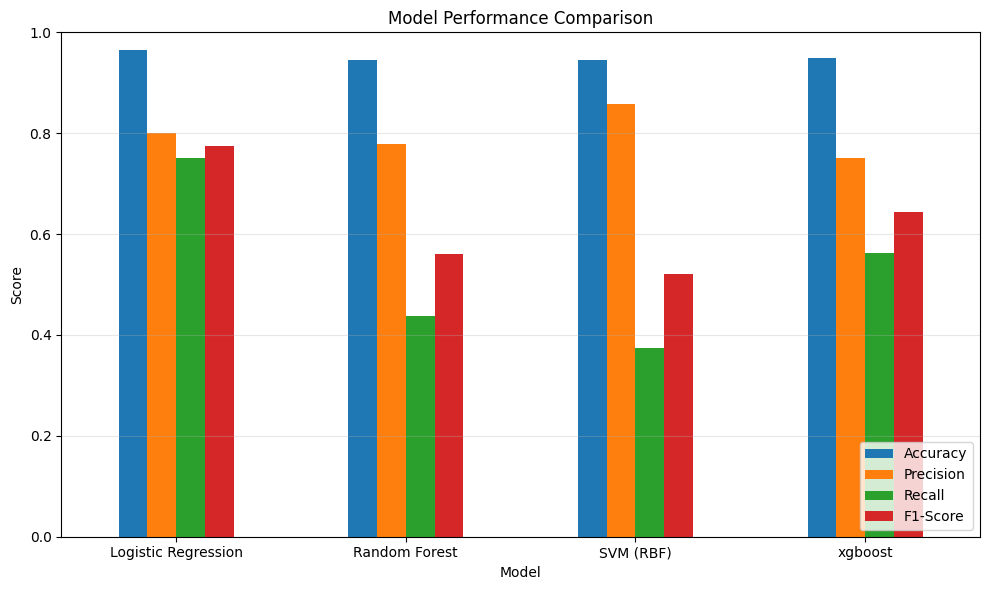

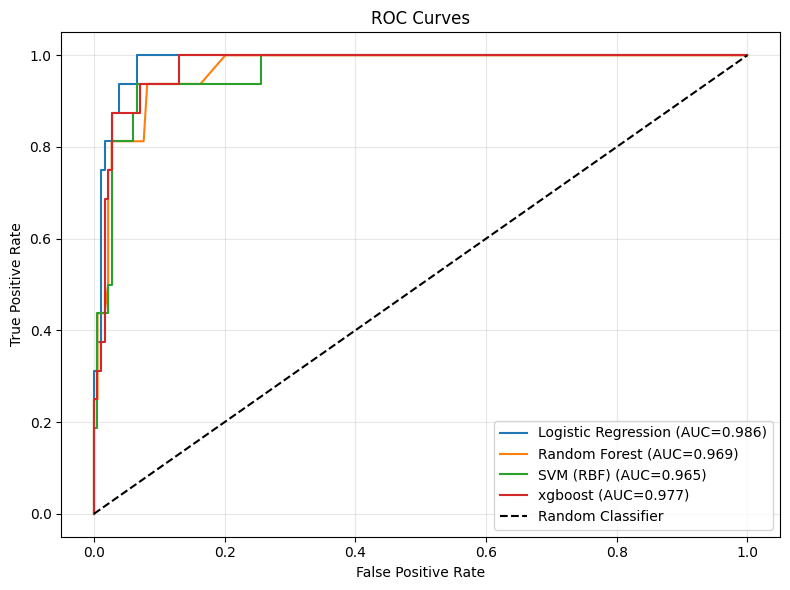

In [9]:
# Model performance comparison plot
plt.figure(figsize=(10, 6))
comparison_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', ax=plt.gca(), rot=0
)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#ROC Curves plot
plt.figure(figsize=(8, 6))
for model_name, res in results.items():
    y_proba = res.get('y_pred_proba')
    if y_proba is None:
        continue
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = res.get('roc_auc')
    plt.plot(fpr, tpr, label=f'{model_name} (AUC={auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

We can see that in the tests performed, the logistic regression model had the best performance among the 4 models chosen in this case, having the best values ​​in accuracy, recall, f-score, and ROC-AUC (remembering that the dataset is small and we should have done more validations to rule out possible bias in the data).

In [10]:
results["Logistic Regression"]

{'model': LogisticRegression(max_iter=1000, random_state=42),
 'accuracy': 0.965,
 'precision': 0.8,
 'recall': 0.75,
 'f1': 0.7741935483870968,
 'roc_auc': 0.9864130434782609,
 'confusion_matrix': array([[181,   3],
        [  4,  12]]),
 'y_pred': array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0]),
 'y_pred_proba': array([2.15290382e-02, 1.26740949e-05, 8.47251578e-0

### 5. Analyze variable importance.

Feature Importance for Logistic Regression Model
(Larger absolute values = stronger impact on predictions)


,Feature,Coefficient,Abs_Coefficient
5,Frequency,0.048033,0.048033
4,VibrationZ,0.042756,0.042756
3,VibrationY,0.036323,0.036323
0,Temperature,0.036282,0.036282
2,VibrationX,0.030013,0.030013
1,Pressure,0.015166,0.015166


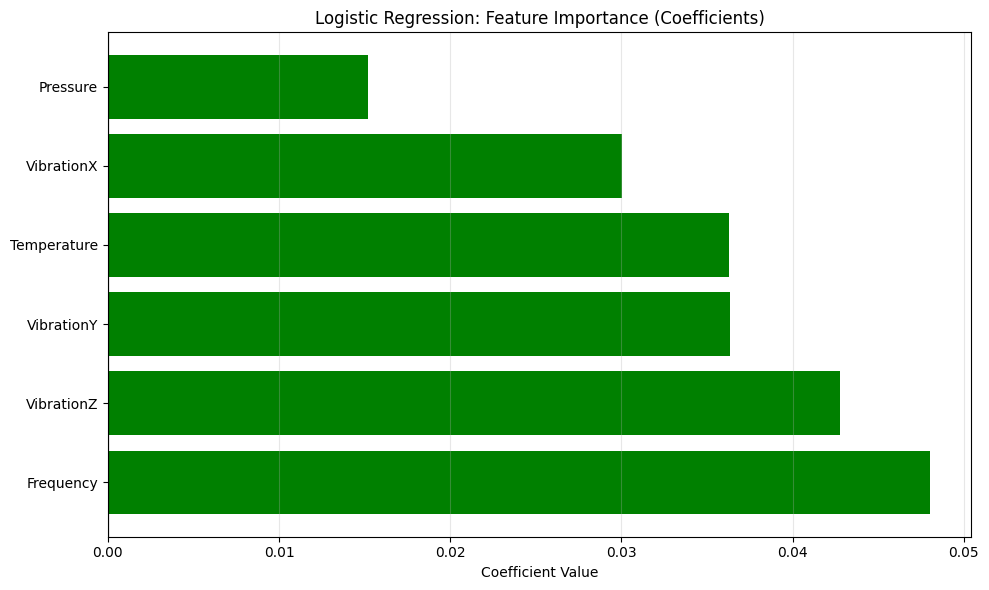

In [13]:

best_model = results["Logistic Regression"]['model']

coefficients = best_model.coef_[0]
feature_importance = pd.DataFrame({
    'Feature': metrics,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

print("Feature Importance for Logistic Regression Model")
print("(Larger absolute values = stronger impact on predictions)")
print("="*60)
display(feature_importance)

# Visualize feature importance
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in feature_importance['Coefficient']]
ax.barh(feature_importance['Feature'], feature_importance['Coefficient'], color=colors)
ax.set_xlabel('Coefficient Value')
ax.set_title('Logistic Regression: Feature Importance (Coefficients)')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


For this trained model, we can see that the strongest coefficient is frequency; it was the variable that proved most efficient in the model's decision to predict failure.